In [68]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from particletracker.fileparser import field_function_from_file
from particletracker.trajectory import solve_trajectory
from particletracker.trajanalysis import show_deviation_degree, show_deviation_in_Z, plot_2d_trajectory, plot_3d_trajectory

In [69]:
''' ==== Particle features ==== '''
m = 939.3      # proton mass (MeV/c²)
q = 1          # proton charge (elementary charge)



''' === Initial conditions === '''
x0, y0, z0 = -0.07573, 0, -0.35   # initial coordinates (m)
v_direction = [((6**0.5)-(2**0.5))/4, 0, ((6**0.5)+(2**0.5))/4]    # velocity vector
Ec0 = 0.3                 # initial particle's kinetic energy 


''' === Trajectory solution === '''
method = 'boris'            # choose between "boris" and "rk4"
step = 1e-12                # time step (s)
total_t = 1e-6              # total elapsed time (s)
traj_distance = 0.685761        # total distance of particle's trajectory in X axis (m)

desired_x = -0.071212
desired_z = 0.335761



''' === Fields === '''
e_field = lambda ponto: [0, 0, 0]       # force electric field to be 0 at all points
b_field = field_function_from_file('2026-01-19_LDE05_Fieldmap_X=-130_130mm_Z=-350_350mm_Imc=2.5A_ID=5481.dat', '\t', 17)

In [70]:
traj = solve_trajectory(m, q, 
                            x0, y0, z0, v_direction, Ec0,
                            b_field, e_field,
                            method, step, total_t, 
                            output_file='traj_calculation_results')

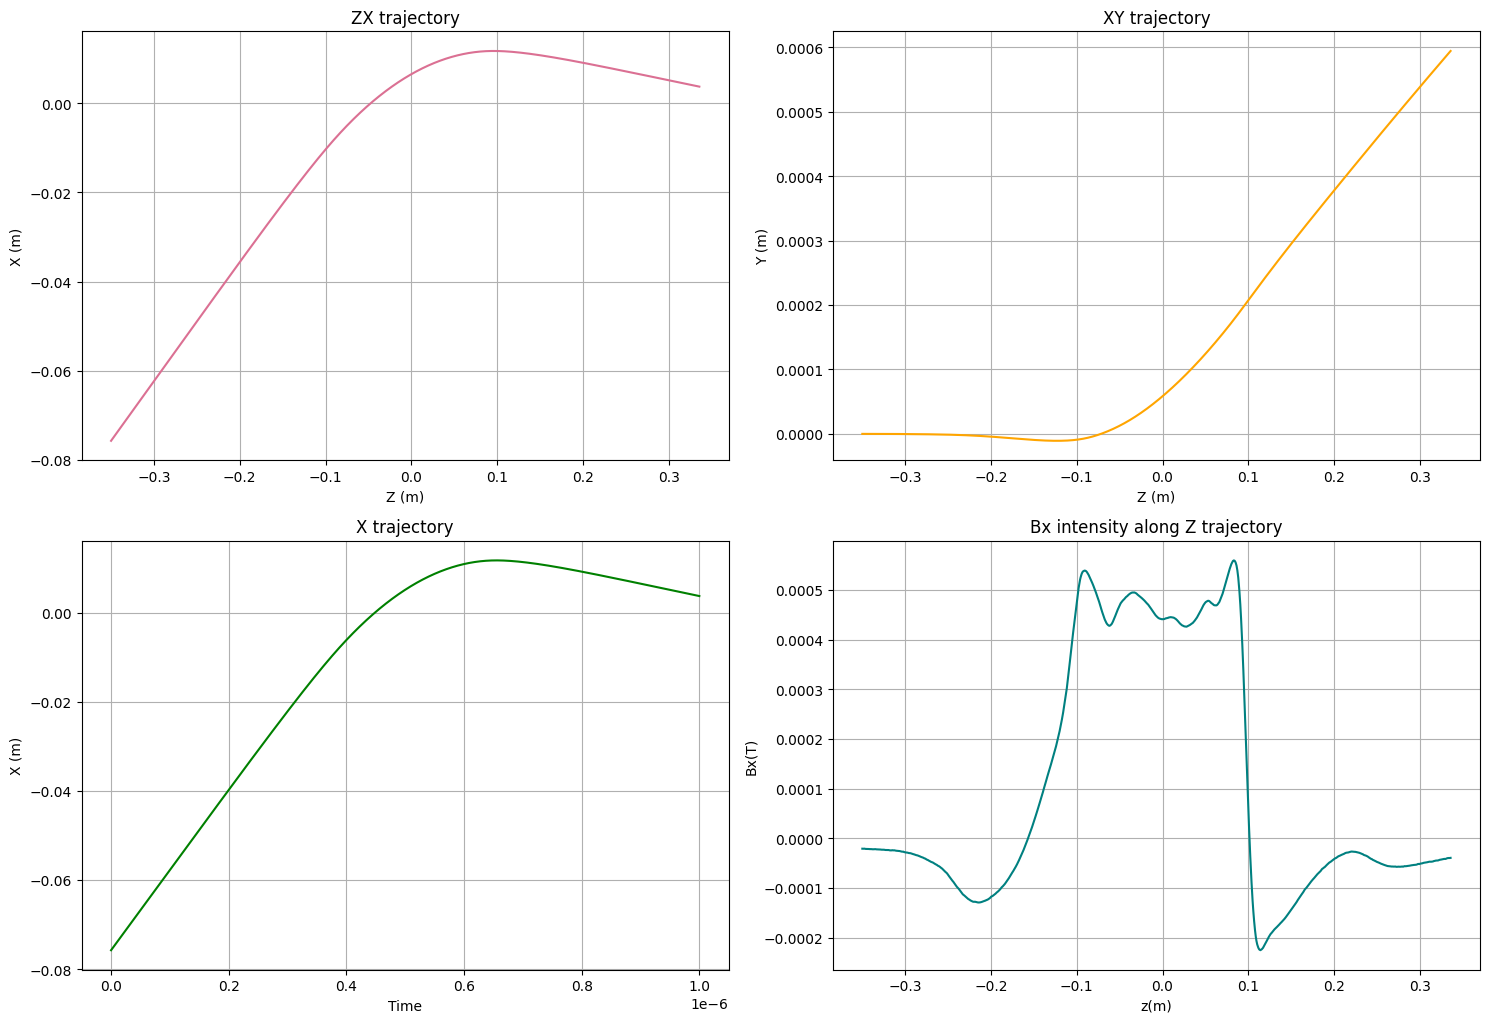

In [71]:
plot_2d_trajectory(traj, total_t, traj_distance)

In [72]:
i =2.5

e = 0.01797*i*i - 0.03061*i + 0.1028

e

0.1385875

In [82]:
currents = [12.5, 10, 9.95, 7.5, 5, 2.5]
energy = [2.5341, 1.6144, 1.534, 0.9055, 0.3918, 0.1008]

chart = pd.DataFrame([energy, currents])

chart = chart.T

chart.columns = ['energia', 'corrente']

chart

,energia,corrente
0,2.5341,12.50
1,1.6144,10.00
2,1.5340,9.95
3,0.9055,7.50
4,0.3918,5.00
5,0.1008,2.50


           3            2
0.0003361 x + 0.009485 x + 0.03595 x - 0.05629


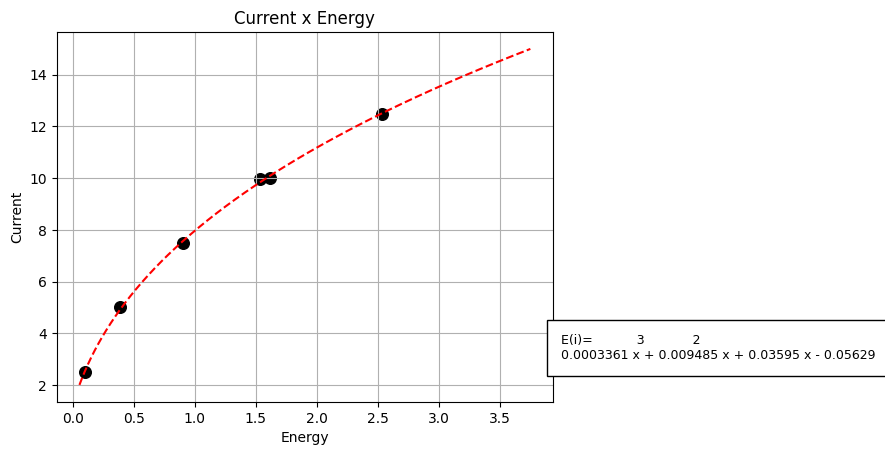

In [97]:
model = np.poly1d(np.polyfit(chart['corrente'], chart['energia'], 3))
plt.scatter(chart['energia'], chart['corrente'], s=70, color='k')
polyline = np.linspace(2, 15, 50)
plt.plot(model(polyline), polyline, color='r', linestyle='--')
plt.xlabel('Energy')
plt.ylabel('Current')
plt.title('Current x Energy')
plt.grid()

plt.text(4, 3, f'E(i)={model}', fontsize=9, color='black', bbox={'facecolor': 'white', 'pad': 10})

plt.savefig('Energy_function_of_current_graph.png', dpi=300, bbox_inches='tight')


print(model)